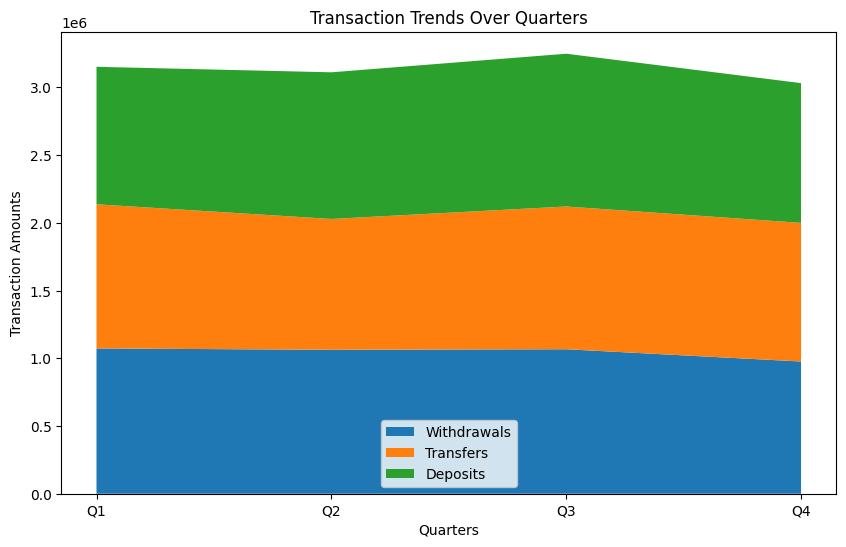

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv(r'Dataset/Comprehensive_Banking_Database.csv')

# Finding the different types of Transactions
transactFrame = pd.DataFrame(data = df, columns = ['Transaction Date', 'Transaction Type', 'Transaction Amount'])
transactTypes = transactFrame['Transaction Type'].unique()

# Finding the total monthly transaction for each type
transDict = {transactionType: dict() for transactionType in transactTypes}
for transactionType in transactTypes:
    monthlyTransact = transactFrame[transactFrame['Transaction Type'] == transactionType]
    monthlyList = []
    for i, row in monthlyTransact.iterrows():
        # Extracting month from string date
        x = row['Transaction Date']
        monthlyList.append((int(x[:x.index('/')]), row['Transaction Amount']))
    
    monthlyDict = {i : 0 for i in range(1,13)}
    for elem in monthlyList:
        monthlyDict[elem[0]] += elem[1]
    transDict[transactionType] = monthlyDict

month_to_quarter = {
    1: 1, 2: 1, 3: 1, 
    4: 2, 5: 2, 6: 2, 
    7: 3, 8: 3, 9: 3, 
    10: 4, 11: 4, 12: 4
}

# Converting months to quarters
quarterSum = {i: {transactionType: 0 for transactionType in transactTypes} for i in range(1, 5)}
for transactionType, monthlyDict in transDict.items():
    for month, amount in monthlyDict.items():
        quarter = month_to_quarter[month]
        quarterSum[quarter][transactionType] += amount


# Plotting stackplot
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
withdrawals = [quarterSum[i]['Withdrawal'] for i in range(1,5)]
transfers = [quarterSum[i]['Transfer'] for i in range(1,5)]
deposits = [quarterSum[i]['Deposit'] for i in range(1,5)]


plt.figure(figsize=(10,6))
plt.stackplot(quarters, withdrawals, transfers, deposits, labels = ['Withdrawals','Transfers','Deposits'])

plt.xlabel('Quarters')
plt.ylabel('Transaction Amounts')
plt.title('Transaction Trends Over Quarters')
plt.legend()

plt.show()